In [1]:
#Imports go here

import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import friedman_config as c

In [2]:
nr_of_seeds = 5 #number of seeds used in the experiments

In [3]:
# Function that returns best params for each pair of (d, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['target_instances', 'd', 'seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('val_rmse','mean'),
                avg_mae=('val_mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse')
    topk_df = agg.groupby(['d', 'target_instances'], group_keys=False).head(k)
    topk_d = topk_df[['d', 'target_instances', 'method', 'avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df

In [4]:
# read all data and tradaboost data
# some data needed fixing, but should not be required if you run all experiments in the scripts provided to obtain the data.

data = pd.read_csv('results/xgboost_ablation_friedman.csv')
xgboost_data = data[data['method'] == 'xgboost']
xgboost_data = xgboost_data.copy()
xgboost_data['method'] = 'XGBoost'
naive_transfer_data_with_dummy = data[data['method'] == 'xgboost_naive_transfer_with_dummy']
naive_transfer_data_with_dummy = naive_transfer_data_with_dummy.copy()
naive_transfer_data_with_dummy['method'] = 'Naïve XGBoost'


mlp_data = pd.read_csv('results/MLP_ablation_friedman.csv', index_col = [0])
mlp_data['method'] = 'Finetuned MLP'

mlp_data = mlp_data.drop_duplicates(subset = ['seed', 'target_instances', 'd', 'base_lr',
       'fine_tuning_lr', 'dropout_rate', 'batch_norm'], keep='first')


tradaboost_data = pd.read_csv('results/tradaboost_ablation_friedman.csv')
tradaboost_data['method'] = 'TradaBoost.R2'
tradaboost_data = tradaboost_data.drop_duplicates()
print(len(tradaboost_data))

11250


In [5]:
#Obtain optimal hyperparams for each method and pair of (d,target_instance)
#NOTE: optimal hyperparams are determined from lowes val rmse
best_LSTransferTreeBoost, best_params_for_us = topk_per_d_per_method(
    f'results/LSTransferTreeBoost_ablation_friedman.csv',
['target_instances', 'd', 'v', 'source_tree_size', 'target_tree_size', 'm_0', 'k'], k=5
)

best_XGBoost, _ = topk_per_d_per_method(
    xgboost_data,
['target_instances', 'd', 'v', 'target_tree_size'], k=nr_of_seeds
)


best_naive_transfer_with_dummy, _ = topk_per_d_per_method(
    naive_transfer_data_with_dummy,
['target_instances', 'd', 'v', 'target_tree_size'], k=nr_of_seeds
)


best_mlp, _ = topk_per_d_per_method(
    mlp_data,
['target_instances', 'd', 'base_lr','fine_tuning_lr','dropout_rate','batch_norm'], k=nr_of_seeds
)


best_tradaboost, k = topk_per_d_per_method(
    tradaboost_data,
['target_instances', 'd', 'n_estimators','lr','tree_size'], k=nr_of_seeds
)

#Combine into one dataframe for visualization
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
df = pd.concat([df, best_naive_transfer_with_dummy])
df = pd.concat([df, best_mlp])
df = pd.concat([df, best_tradaboost])


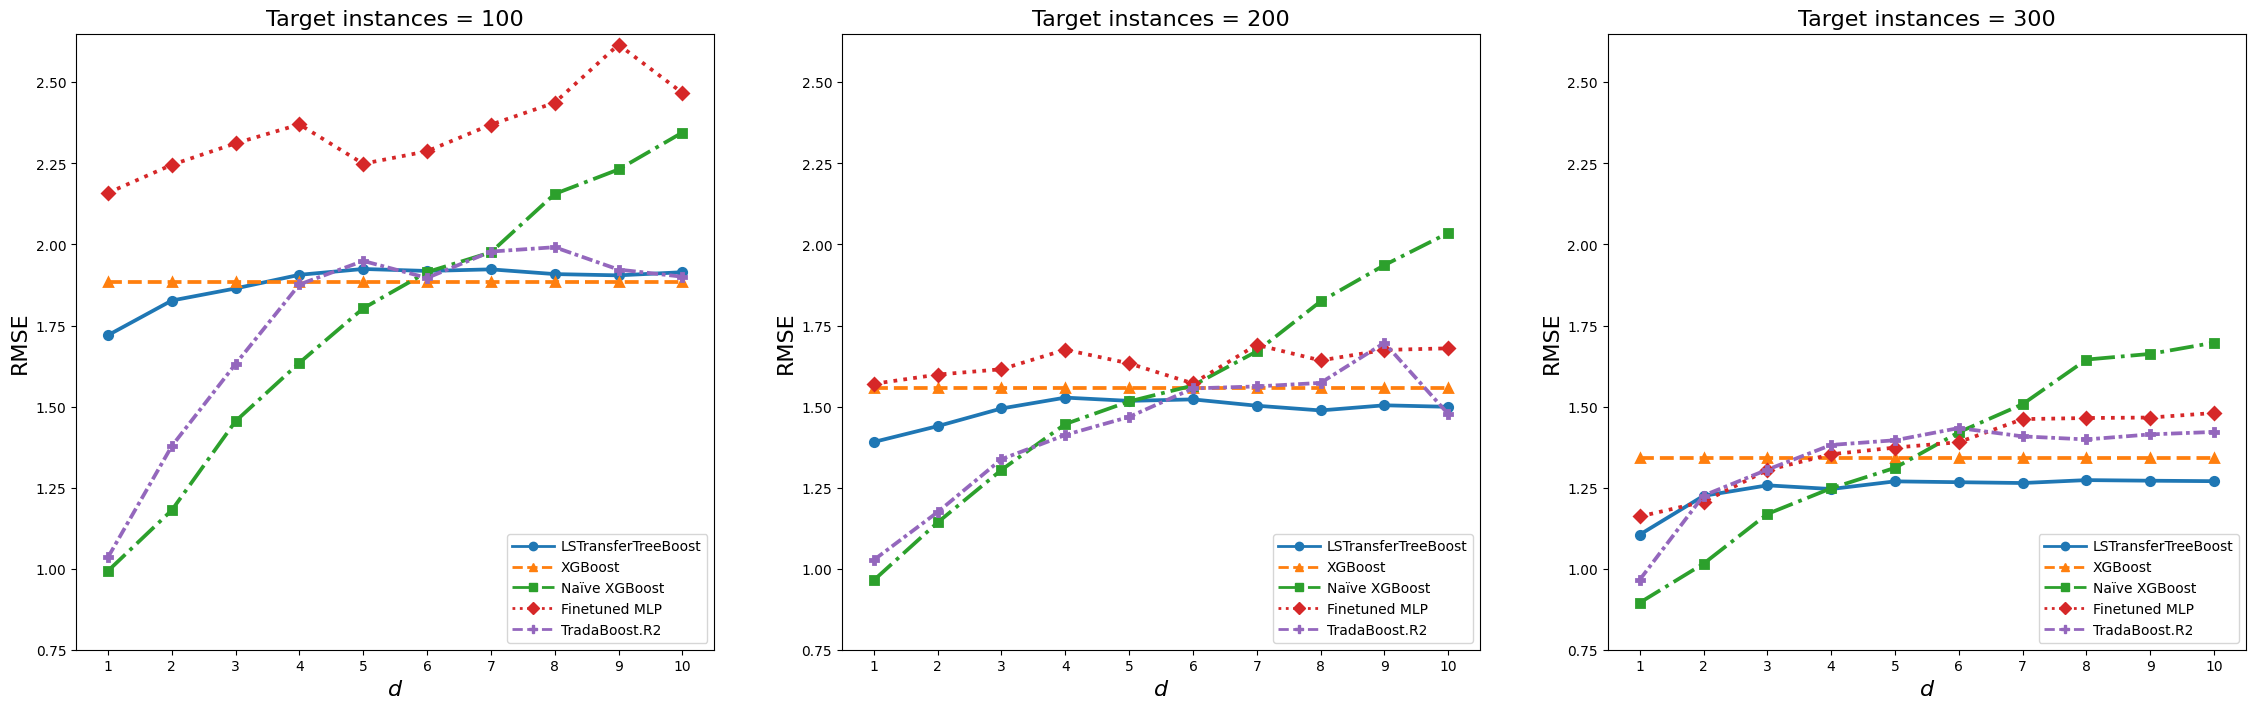

In [6]:
# Plot average test RMSE:s for best hyperparams
i=0
from matplotlib.lines import Line2D

plt.figure(figsize = (28,8))
for target_instances in c.target_instances_list:
    plt.subplot(1,len(c.target_instances_list),i+1)
    dat = df[df['target_instances'] == target_instances]
    sns.pointplot(data = dat, x = 'd', y = 'rmse', hue = 'method',  errorbar=None, 
                    markers=['o', '^', 's', 'D', 'P'], markersize=6, linestyles=['-', '--', '-.', ':', (0, (3, 1, 1, 1))])
   
    # grab the current legend
    handles, labels = plt.gca().get_legend_handles_labels()

    # rebuild legend with longer lines
    new_handles = []
    for h in handles:
        if isinstance(h, Line2D):
            new_handles.append(Line2D(
                [0], [0], 
                color=h.get_color(),
                linestyle=h.get_linestyle(),
                marker=h.get_marker(),
                markersize=6,
                linewidth=2,
            ))
        else:
            new_handles.append(h)
    #plt.legend(loc="lower right")
    plt.legend(new_handles, labels, handlelength=3, handletextpad=0.5, loc="lower right")  # increase handlelength to "extend" line
    plt.gca().set_xlabel('$d$', fontsize=16)
    plt.gca().set_ylabel('RMSE', fontsize=16)
    plt.gca().set_title(f'Target instances = {target_instances}', fontsize=16)
    #plt.ylabel('RMSE')
    #plt.title(f'Target instances = {target_instances}')
    plt.ylim([0.75,2.65])
    i+=1
plt.savefig('vizes/friedman.png', dpi = 300, bbox_inches = 'tight', pad_inches = 0.1)
plt.show()

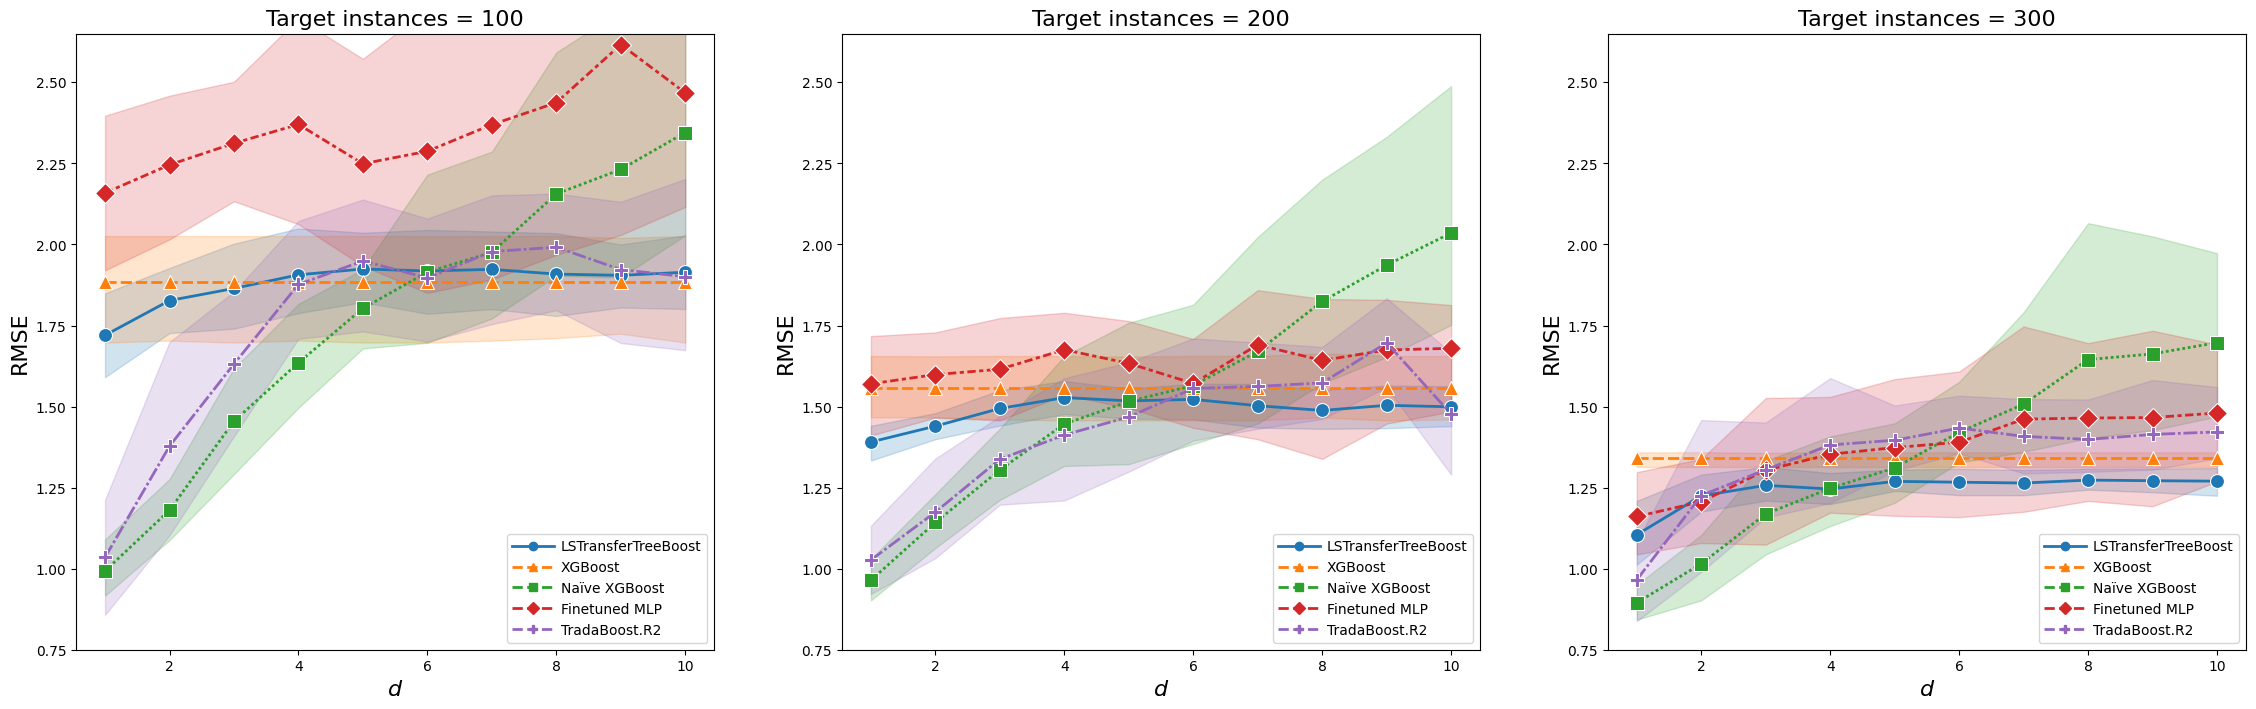

In [7]:
# Plot average test RMSE:s for best hyperparams, with confidence intervals
i = 0
plt.figure(figsize = (28,8))
for target_instances in c.target_instances_list:
    plt.subplot(1,len(c.target_instances_list),i+1)
    dat = df[df['target_instances'] == target_instances].copy()
    # pick markers for your methods
    marker_dict = {
        'LSTransferTreeBoost': 'o',
        'XGBoost': '^',
        'Naïve XGBoost': 's',
        'Finetuned MLP': 'D',
        'TradaBoost.R2': 'P'
    }

    linestyles_dict = {
        'LSTransferTreeBoost': '-',
        'XGBoost': '--', 
        'Naïve XGBoost': '-.', 
        'Finetuned MLP': ':', 
        'TradaBoost.R2': (0, (3, 1, 1, 1)),
    }

    linestyles_dict=['-', '--', '-.', ':', (0, (3, 1, 1, 1))]

    
    sns.lineplot(
        data=dat,
        x='d', y='rmse', hue='method',
        style='method',                # needed to activate markers/dashes mapping
        markers=marker_dict,            # adds shaded confidence intervals
        linewidth=2,
        markersize=10,
        errorbar='ci'
    )
   
    # grab the current legend
    handles, labels = plt.gca().get_legend_handles_labels()

    # rebuild legend with longer lines
    new_handles = []
    for h in handles:
        if isinstance(h, Line2D):
            new_handles.append(Line2D(
                [0], [0], 
                color=h.get_color(),
                linestyle=h.get_linestyle(),
                marker=h.get_marker(),
                markersize=6,
                linewidth=2,
            ))
        else:
            new_handles.append(h)
    #plt.legend(loc="lower right")
    plt.legend(new_handles, labels, handlelength=3, handletextpad=0.5, loc="lower right")  # increase handlelength to "extend" line
    plt.gca().set_xlabel('$d$', fontsize=16)
    plt.gca().set_ylabel('RMSE', fontsize=16)
    plt.gca().set_title(f'Target instances = {target_instances}', fontsize=16)


    #plt.ylabel('RMSE')
    #plt.title(f'Target instances = {target_instances}')
    plt.ylim([0.75,2.65])
    i+=1
plt.savefig('vizes/friedman_ci.png', dpi = 300, bbox_inches = 'tight', pad_inches = 0.1)
plt.show()


